In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
from dotenv import load_dotenv

In [10]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [8]:
load_dotenv()
data_path = os.getenv("DATA_PATH")
path = os.path.join(data_path, r"raw\train_transaction.csv\train_transaction.csv")
train_transaction = pd.read_csv(path)

In [9]:
path

'D:\\IT\\projects\\fraud_detection\\data\\raw\\train_transaction.csv\\train_transaction.csv'

In [11]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
train_transaction.shape

(590540, 394)

In [16]:
train_transaction.describe()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,NaN,NaN,NaN,3282269.5,170474.358321,2987000.0,3134634.75,3282269.5,3429904.25,3577539.0
isFraud,590540.0,NaN,NaN,NaN,0.03499,0.183755,0.0,0.0,0.0,0.0,1.0
TransactionDT,590540.0,NaN,NaN,NaN,7372311.310116,4617223.64654,86400.0,3027057.75,7306527.5,11246620.0,15811131.0
TransactionAmt,590540.0,NaN,NaN,NaN,135.027176,239.162522,0.251,43.321,68.769,125.0,31937.391
ProductCD,590540,5,W,439670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
V335,82351.0,NaN,NaN,NaN,59.16455,387.62948,0.0,0.0,0.0,0.0,55125.0
V336,82351.0,NaN,NaN,NaN,28.530903,274.57692,0.0,0.0,0.0,0.0,55125.0
V337,82351.0,NaN,NaN,NaN,55.352422,668.486833,0.0,0.0,0.0,0.0,104060.0
V338,82351.0,NaN,NaN,NaN,151.160542,1095.034387,0.0,0.0,0.0,0.0,104060.0


In [19]:
train_transaction["isFraud"].value_counts()
train_transaction["isFraud"].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

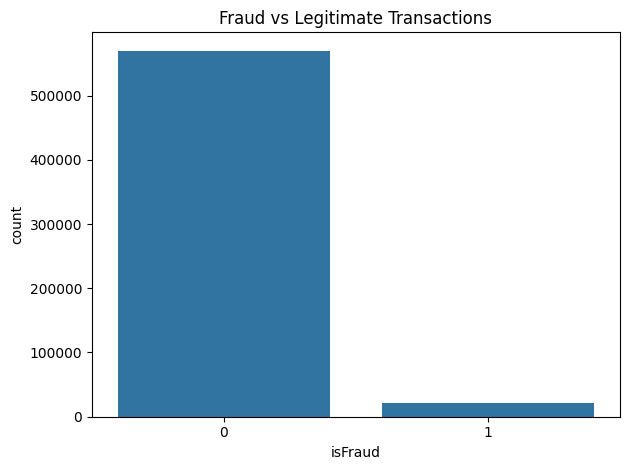

In [20]:
sns.countplot(data=train_transaction, x="isFraud")
plt.title("Fraud vs Legitimate Transactions")
plt.tight_layout()
plt.show()

In [99]:
print(len(train_transaction.isna().sum()[train_transaction.isna().sum() > 0])/len(train_transaction.columns))

0.9468354430379747


In [101]:
train_transaction.isna().sum()[train_transaction.isna().sum() == 0].index

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
       'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'time_bin'],
      dtype='object')

In [25]:
missing = (train_transaction.isna().mean().sort_values(ascending=False) * 100)

In [34]:
no_digit_cols = [col for col in train_transaction.columns if not re.search(r'\d', col)]
missing_no_digit = (train_transaction[no_digit_cols].isna().mean().sort_values(ascending=False) * 100)

In [37]:
missing.head(30)

dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
D6       87.606767
D9       87.312290
D8       87.312290
V153     86.123717
V149     86.123717
V141     86.123717
V146     86.123717
V154     86.123717
V162     86.123717
V142     86.123717
V158     86.123717
V161     86.123717
V157     86.123717
V138     86.123717
V139     86.123717
V148     86.123717
V140     86.123717
V155     86.123717
V156     86.123717
V147     86.123717
V163     86.123717
V143     86.122701
V145     86.122701
V144     86.122701
V165     86.122701
dtype: float64

In [43]:
missing.describe()

count    394.000000
mean      41.073431
std       35.895976
min        0.000000
25%        0.214888
50%       28.612626
75%       77.913435
max       93.628374
dtype: float64

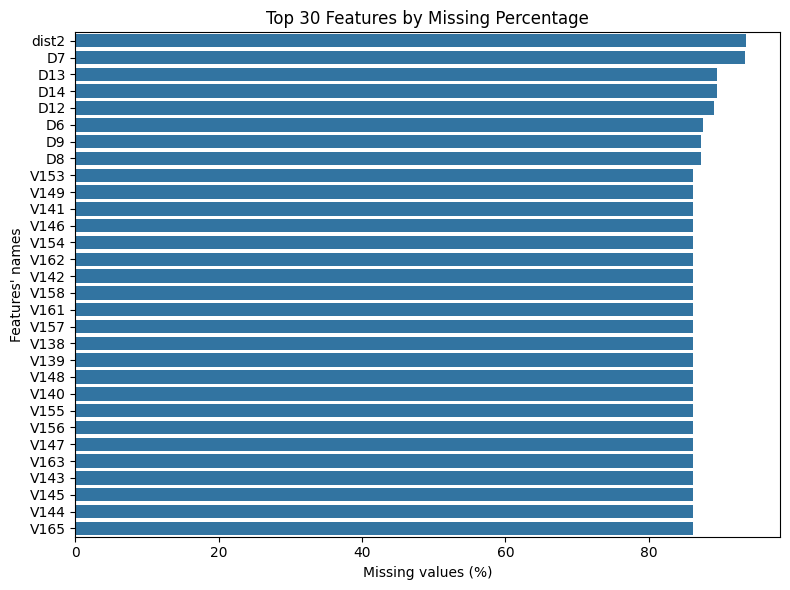

In [42]:
plt.figure(figsize=(8, 6))
sns.barplot(data=missing.head(30), orient="h")
plt.title("Top 30 Features by Missing Percentage")
plt.xlabel("Missing values (%)")
plt.ylabel("Features' names")
plt.tight_layout()
plt.show()

In [47]:
data_types_distribution = train_transaction.dtypes
data_types_distribution.value_counts()
data_types_distribution.value_counts(normalize=True) * 100

float64    95.431472
object      3.553299
int64       1.015228
Name: proportion, dtype: float64

In [51]:
print(train_transaction.select_dtypes(include="number").shape)
print(train_transaction.select_dtypes(include="object").shape)

(590540, 380)
(590540, 14)


In [52]:
train_transaction["TransactionDT"].describe()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

In [54]:
train_transaction["TransactionDT"].min(), train_transaction["TransactionDT"].max()

(np.int64(86400), np.int64(15811131))

In [56]:
train_transaction["TransactionDT"].sort_values().head(), train_transaction["TransactionDT"].sort_values().tail()

(0    86400
 1    86401
 2    86469
 3    86499
 4    86506
 Name: TransactionDT, dtype: int64,
 590535    15811047
 590536    15811049
 590537    15811079
 590538    15811088
 590539    15811131
 Name: TransactionDT, dtype: int64)

In [59]:
train_transaction[["TransactionDT", "isFraud"]].sort_values("TransactionDT").head(20)

,TransactionDT,isFraud
0,86400,0
1,86401,0
2,86469,0
3,86499,0
4,86506,0
5,86510,0
6,86522,0
7,86529,0
8,86535,0
9,86536,0


In [66]:
train_transaction["time_bin"] = pd.qcut(train_transaction["TransactionDT"], q=20, duplicates="drop")

In [82]:
fraud_by_time = (train_transaction.groupby("time_bin", observed=True)['isFraud'].mean()).sort_index()

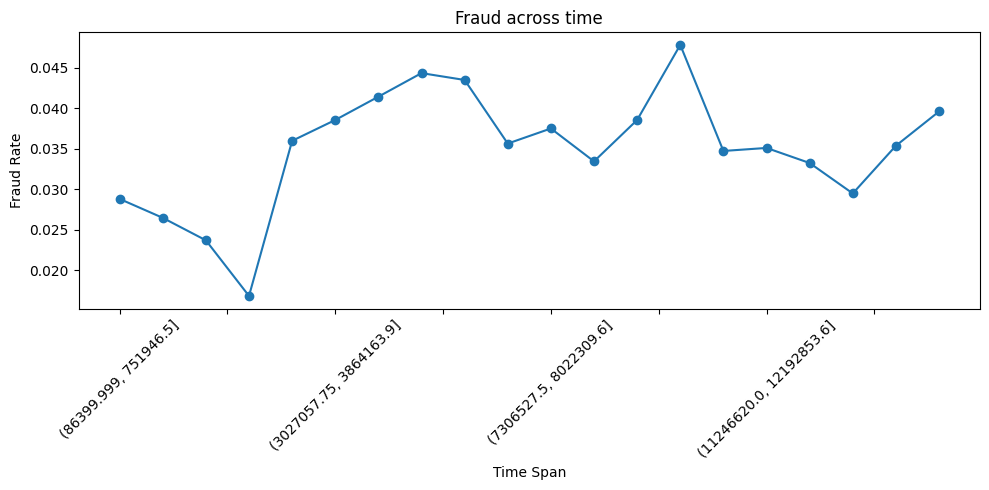

In [102]:
fraud_by_time.plot(figsize = (10, 5), marker='o')
plt.title("Fraud across time")
plt.xlabel("Time Span")
plt.ylabel("Fraud Rate")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [96]:
len(train_transaction) == train_transaction["TransactionID"].nunique()

True